<a href="https://colab.research.google.com/github/KurniaYufi/nlp-sentiment-analisis/blob/main/Week4/Week4_Bibit_BoW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bag of Words (BoW) — Bibit App Reviews

Notebook ini menerapkan metode **Bag of Words (BoW)** secara lengkap pada dataset ulasan aplikasi Bibit.

## Alur Pengerjaan
1. Load & Eksplorasi Dataset
2. Tokenisasi, Stopword Removal, dan Lemmatisasi
3. Identifikasi Unique Words & Frekuensi
4. Pembuatan Word-to-Number Mapping
5. Pembuatan BoW Matrix dengan CountVectorizer
6. Analisis & Visualisasi Hasil BoW
7. BoW per Kelas Sentimen

## 0. Install & Import Library

In [ ]:
# Install library yang dibutuhkan
!pip install nltk scikit-learn pandas matplotlib seaborn wordcloud -q

In [ ]:
import nltk
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

# Download resource NLTK
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

print("Semua library berhasil diimport!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Semua library berhasil diimport!


[nltk_data] Downloading package wordnet to /root/nltk_data...


## 1. Load & Eksplorasi Dataset

In [ ]:
# Load dataset Bibit reviews
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/NLP/bibit_reviews_cleaned.csv')

print("=" * 50)
print("INFO DATASET")
print("=" * 50)
print(f"Jumlah baris   : {df.shape[0]:,}")
print(f"Jumlah kolom   : {df.shape[1]}")
print(f"Nama kolom     : {df.columns.tolist()}")
print()
print(df.head(3))

Mounted at /content/drive
INFO DATASET
Jumlah baris   : 36,237
Jumlah kolom   : 8
Nama kolom     : ['content', 'score', 'at', 'thumbsUpCount', 'replyContent', 'sentiment', 'final_text', 'tokens_final']

                                             content  score  \
0                                 okelah buat nabung      5   
1  Apk rekomendasi untuk pemula yang ingin tau te...      5   
2                                               good      5   

                    at  thumbsUpCount  \
0  2026-03-30 01:40:09              0   
1  2026-03-30 01:38:55              0   
2  2026-03-29 17:29:32              0   

                                        replyContent sentiment  \
0  Terima kasih telah memilih Bibit sebagai platf...  positive   
1  Terima kasih telah memilih Bibit sebagai platf...  positive   
2  Terima kasih telah memilih Bibit sebagai platf...  positive   

                   final_text                             tokens_final  
0                  oke nabung            


Distribusi Label Sentimen:
sentiment
positive    27065
negative     6968
neutral      2204
Name: count, dtype: int64



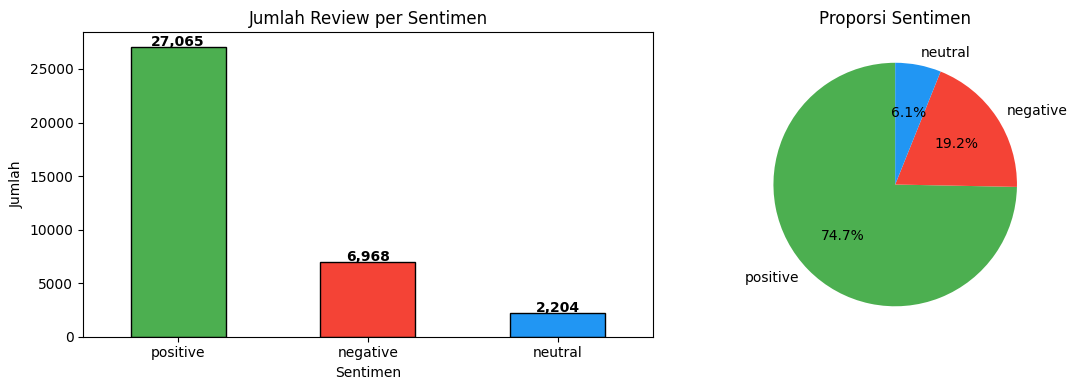

In [ ]:
# Distribusi Sentimen
print("\nDistribusi Label Sentimen:")
print(df['sentiment'].value_counts())
print()

# Visualisasi distribusi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
sentiment_counts = df['sentiment'].value_counts()
colors = ['#4CAF50', '#F44336', '#2196F3']
sentiment_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Jumlah Review per Sentimen')
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(sentiment_counts):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
sentiment_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                      colors=colors, startangle=90)
axes[1].set_title('Proporsi Sentimen')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
# Cek missing values pada kolom yang digunakan
print("Missing values pada kolom 'final_text':", df['final_text'].isna().sum())

# Drop baris yang tidak memiliki final_text
df = df.dropna(subset=['final_text']).reset_index(drop=True)
print(f"Dataset setelah drop NA: {df.shape[0]:,} baris")

Missing values pada kolom 'final_text': 0
Dataset setelah drop NA: 36,237 baris


## 2. Preprocessing — Tokenisasi, Stopword Removal & Lemmatisasi

Dataset sudah memiliki kolom `final_text` (teks yang telah dibersihkan) dan `tokens_final` (token). Kita akan menggunakan `final_text` sebagai corpus, lalu menerapkan pipeline preprocessing untuk memastikan konsistensi.

> **Catatan:** Karena teks sudah dalam Bahasa Indonesia, stopword Bahasa Indonesia ditambahkan secara manual.

In [ ]:
# Daftar stopword Bahasa Indonesia tambahan
indonesian_stopwords = [
    'yang', 'dan', 'di', 'ke', 'dari', 'dengan', 'ini', 'itu', 'untuk',
    'adalah', 'ada', 'pada', 'atau', 'juga', 'sudah', 'saya', 'kami',
    'kita', 'mereka', 'anda', 'bisa', 'akan', 'tidak', 'lebih', 'agar',
    'jika', 'bila', 'saat', 'oleh', 'karena', 'namun', 'tetapi',
    'sudah', 'belum', 'pun', 'pula', 'sangat', 'sekali', 'nih', 'sih',
    'deh', 'dong', 'ya', 'yg', 'utk', 'dgn', 'dr', 'krn', 'sy', 'tp',
    'kak', 'kakak', 'hai', 'halo', 'terima', 'kasih', 'hub', 'info',
    'kami', 'tim', 'support', 'app', 'apk', 'aplikasi', 'bibit', 'wa',
    'chat', 'live', 'email', 'link', 'klik'
]

# Gabung stopwords Inggris + Indonesia
all_stopwords = set(stopwords.words('english')).union(set(indonesian_stopwords))

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Pipeline preprocessing:
    1. Hapus karakter non-alfabet
    2. Lowercase
    3. Tokenisasi
    4. Hapus stopwords
    5. Lemmatisasi
    """
    # 1. Hapus karakter non-alfabet (angka, tanda baca, simbol)
    text = re.sub('[^a-zA-Z]', ' ', str(text))
    # 2. Lowercase
    text = text.lower()
    # 3. Tokenisasi
    tokens = text.split()
    # 4. Hapus stopwords & token pendek (<= 2 karakter)
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 2]
    # 5. Lemmatisasi
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Terapkan preprocessing ke seluruh dataset
print("Memproses teks...")
df['processed_text'] = df['final_text'].apply(preprocess_text)
print("Preprocessing selesai!")

# Tampilkan contoh hasil
print("\nContoh hasil preprocessing:")
print("-" * 60)
for idx in [0, 3, 5]:
    print(f"Original  : {df['final_text'].iloc[idx]}")
    print(f"Processed : {df['processed_text'].iloc[idx]}")
    print(f"Sentimen  : {df['sentiment'].iloc[idx]}")
    print("-" * 60)

Memproses teks...
Preprocessing selesai!

Contoh hasil preprocessing:
------------------------------------------------------------
Original  : oke nabung
Processed : oke nabung
Sentimen  : positive
------------------------------------------------------------
Original  : manager investasi bodo nitip duit minus gue main main saham profit fluktuasi nilai saham manager investasi kompeten tambah emas
Processed : manager investasi bodo nitip duit minus gue main main saham profit fluktuasi nilai saham manager investasi kompeten tambah emas
Sentimen  : negative
------------------------------------------------------------
Original  : bukaa yaa
Processed : bukaa yaa
Sentimen  : negative
------------------------------------------------------------


In [ ]:
# Buat corpus: list teks yang sudah diproses (hapus yang kosong)
corpus = df[df['processed_text'].str.strip() != '']['processed_text'].tolist()
corpus_df = df[df['processed_text'].str.strip() != ''].copy()

print(f"Total dokumen dalam corpus: {len(corpus):,}")
print(f"\nContoh 5 dokumen pertama:")
for i, doc in enumerate(corpus[:5]):
    print(f"  [{i}] {doc}")

Total dokumen dalam corpus: 36,096

Contoh 5 dokumen pertama:
  [0] oke nabung
  [1] rekomendasi mula tau dunia
  [2] good
  [3] manager investasi bodo nitip duit minus gue main main saham profit fluktuasi nilai saham manager investasi kompeten tambah emas
  [4] bagus banget


## 3. Identifikasi Unique Words & Frekuensi

Setelah preprocessing, kita identifikasi seluruh kata unik yang ada di corpus beserta frekuensinya.

In [ ]:
# Kumpulkan semua kata dari seluruh dokumen
all_words = []
for doc in corpus:
    for word in doc.split():
        all_words.append(word)

# Hitung frekuensi setiap kata
word_frequencies = Counter(all_words)

# Unique words
unique_words = list(word_frequencies.keys())

print(f"Total kata (dengan duplikat) : {len(all_words):,}")
print(f"Total kata unik              : {len(unique_words):,}")
print()
print("Top 20 kata paling sering muncul:")
print("-" * 35)
for rank, (word, freq) in enumerate(word_frequencies.most_common(20), 1):
    bar = '█' * (freq // 500)
    print(f"{rank:2}. {word:<20} {freq:>6,}  {bar}")

Total kata (dengan duplikat) : 195,038
Total kata unik              : 3,727

Top 20 kata paling sering muncul:
-----------------------------------
 1. kode                  5,226  ██████████
 2. bagus                 4,291  ████████
 3. mula                  4,095  ████████
 4. mudah                 3,937  ███████
 5. masuk                 3,760  ███████
 6. pakai                 3,709  ███████
 7. banget                3,104  ██████
 8. cashback              2,851  █████
 9. moga                  2,404  ████
10. ajar                  2,288  ████
11. dana                  2,060  ████
12. mantap                2,036  ████
13. coba                  1,972  ███
14. bantu                 1,962  ███
15. uang                  1,833  ███
16. investasi             1,691  ███
17. keren                 1,682  ███
18. cair                  1,646  ███
19. jual                  1,604  ███
20. daftar                1,515  ███


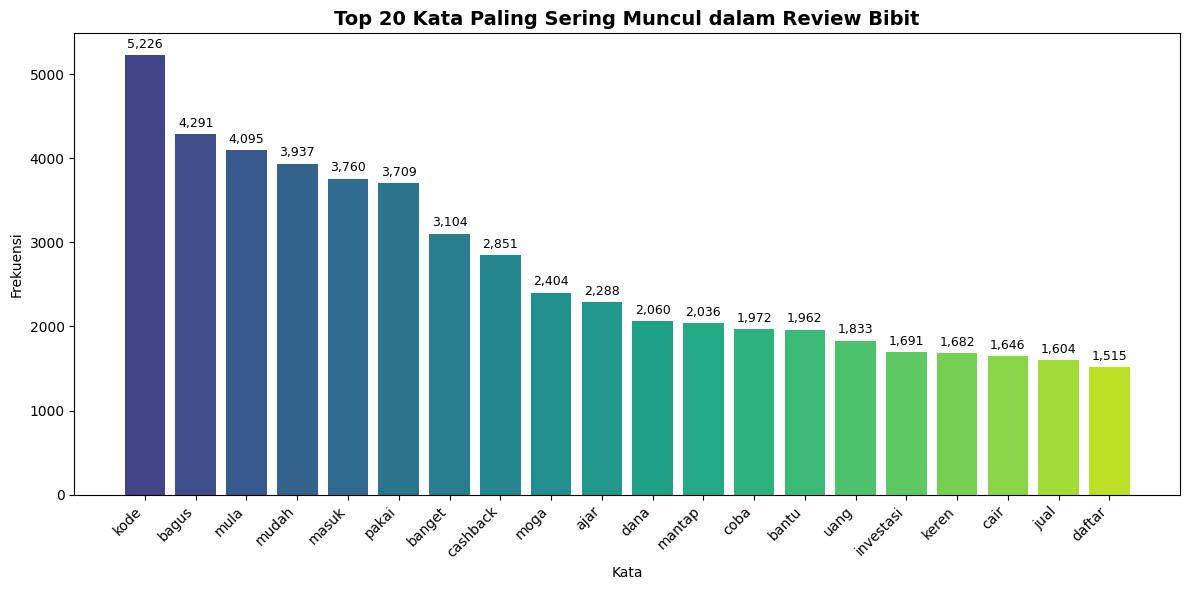

In [ ]:
# Visualisasi 20 kata teratas
top_words = word_frequencies.most_common(20)
words, freqs = zip(*top_words)

plt.figure(figsize=(12, 6))
bars = plt.bar(words, freqs, color=plt.cm.viridis(np.linspace(0.2, 0.9, len(words))))
plt.title('Top 20 Kata Paling Sering Muncul dalam Review Bibit', fontsize=14, fontweight='bold')
plt.xlabel('Kata')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45, ha='right')
for bar, freq in zip(bars, freqs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{freq:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Word-to-Number Mapping (Sorted by Frequency)

Setiap kata unik dipetakan ke angka berdasarkan urutan frekuensi tertinggi ke terendah.

In [ ]:
# Urutkan kata berdasarkan frekuensi (descending)
sorted_words = sorted(word_frequencies.items(), key=lambda item: item[1], reverse=True)

# Buat mapping word -> nomor (mulai dari 1)
word_to_number = {}
for i, (word, frequency) in enumerate(sorted_words):
    word_to_number[word] = i + 1

# Mapping terbalik: nomor -> kata
number_to_word = {v: k for k, v in word_to_number.items()}

print("Word-to-Number Mapping (Top 30):")
print(f"{'No':>4}  {'Kata':<20}  {'Frekuensi':>10}")
print("-" * 40)
for word, freq in sorted_words[:30]:
    num = word_to_number[word]
    print(f"{num:>4}  {word:<20}  {freq:>10,}")

print(f"\n... dan {len(word_to_number) - 30:,} kata lainnya")
print(f"\nTotal vocabulary size: {len(word_to_number):,} kata")

Word-to-Number Mapping (Top 30):
  No  Kata                   Frekuensi
----------------------------------------
   1  kode                       5,226
   2  bagus                      4,291
   3  mula                       4,095
   4  mudah                      3,937
   5  masuk                      3,760
   6  pakai                      3,709
   7  banget                     3,104
   8  cashback                   2,851
   9  moga                       2,404
  10  ajar                       2,288
  11  dana                       2,060
  12  mantap                     2,036
  13  coba                       1,972
  14  bantu                      1,962
  15  uang                       1,833
  16  investasi                  1,691
  17  keren                      1,682
  18  cair                       1,646
  19  jual                       1,604
  20  daftar                     1,515
  21  buka                       1,488
  22  referal                    1,487
  23  tarik                  

## 5. Pembuatan BoW Matrix dengan CountVectorizer

**CountVectorizer** dari scikit-learn digunakan untuk membuat representasi BoW secara efisien. Parameter yang digunakan:
- `max_features`: batasi vocabulary ke N kata teratas
- `min_df`: abaikan kata yang muncul di kurang dari N dokumen
- `max_df`: abaikan kata yang terlalu umum (muncul di lebih dari X% dokumen)

In [ ]:
# Buat BoW Matrix
# max_features=1000: ambil 1000 kata paling sering
# min_df=5: kata harus muncul minimal di 5 dokumen
# max_df=0.95: abaikan kata yang muncul di lebih dari 95% dokumen
cv = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

bow_matrix = cv.fit_transform(corpus)

print("=" * 50)
print("HASIL BOW MATRIX")
print("=" * 50)
print(f"Ukuran matrix          : {bow_matrix.shape}")
print(f"  - Jumlah dokumen     : {bow_matrix.shape[0]:,}")
print(f"  - Jumlah fitur/kata  : {bow_matrix.shape[1]:,}")
print(f"Tipe data              : {type(bow_matrix)}")
print(f"Non-zero elements      : {bow_matrix.nnz:,}")
print(f"Sparsity               : {(1 - bow_matrix.nnz / (bow_matrix.shape[0]*bow_matrix.shape[1])):.2%}")

HASIL BOW MATRIX
Ukuran matrix          : (36096, 1000)
  - Jumlah dokumen     : 36,096
  - Jumlah fitur/kata  : 1,000
Tipe data              : <class 'scipy.sparse._csr.csr_matrix'>
Non-zero elements      : 165,775
Sparsity               : 99.54%


In [ ]:
# Tampilkan vocabulary (fitur) yang digunakan
feature_names = cv.get_feature_names_out()
print(f"Vocabulary ({len(feature_names)} kata):")
print(feature_names[:50])
print("...")

Vocabulary (1000 kata):
['aamiin' 'acc' 'account' 'adakan' 'adminnya' 'aduh' 'advisor' 'agam'
 'ahli' 'aja' 'ajaib' 'ajak' 'ajar' 'aju' 'akses' 'aktif' 'aku' 'akun'
 'ala' 'alam' 'alangkah' 'alhamdulilah' 'alhamdulillah' 'alhasil' 'alias'
 'allah' 'alternatif' 'aman' 'amanah' 'ambil' 'amin' 'ampun' 'anak'
 'andai' 'andal' 'android' 'ane' 'aneh' 'anggap' 'angka' 'anjir' 'apa'
 'apaapa' 'aperd' 'apknya' 'apl' 'application' 'appnya' 'apps' 'april']
...


In [ ]:
# Tampilkan BoW Matrix dalam bentuk DataFrame (untuk 10 dokumen pertama)
bow_array = bow_matrix.toarray()
bow_df = pd.DataFrame(bow_array[:10], columns=feature_names)

# Tampilkan hanya kolom yang ada nilainya (non-zero)
non_zero_cols = bow_df.columns[(bow_df != 0).any()]
print(f"Contoh BoW Matrix (10 dokumen pertama, {len(non_zero_cols)} kolom non-zero):")
bow_df[non_zero_cols].head(10)

Contoh BoW Matrix (10 dokumen pertama, 41 kolom non-zero):


,akses,bagus,bahaya,banget,benah,duit,dunia,emas,fitur,good,...,salah,selfie,tambah,tarik,tau,total,uang,verifikasi,wajah,yaa
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
6,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,1,0,1,0,1,0,0,0,0,0,...,1,1,0,0,0,0,0,2,1,0
8,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
9,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,0


In [ ]:
# Contoh representasi BoW untuk 1 dokumen
idx = 3  # ganti untuk dokumen lain
doc_text = corpus[idx]
doc_vector = bow_array[idx]

# Ambil kata yang muncul pada dokumen ini
present_words = [(feature_names[i], doc_vector[i]) for i in range(len(doc_vector)) if doc_vector[i] > 0]

print(f"Dokumen [{idx}]  : '{doc_text}'")
print(f"Sentimen       : {corpus_df['sentiment'].iloc[idx]}")
print(f"Representasi BoW:")
for word, count in present_words:
    print(f"  '{word}' → {int(count)}")

Dokumen [3]  : 'manager investasi bodo nitip duit minus gue main main saham profit fluktuasi nilai saham manager investasi kompeten tambah emas'
Sentimen       : negative
Representasi BoW:
  'duit' → 1
  'emas' → 1
  'gue' → 1
  'investasi' → 2
  'main' → 2
  'manager' → 2
  'minus' → 1
  'nilai' → 1
  'profit' → 1
  'saham' → 2
  'tambah' → 1


## 6. Analisis & Visualisasi Hasil BoW

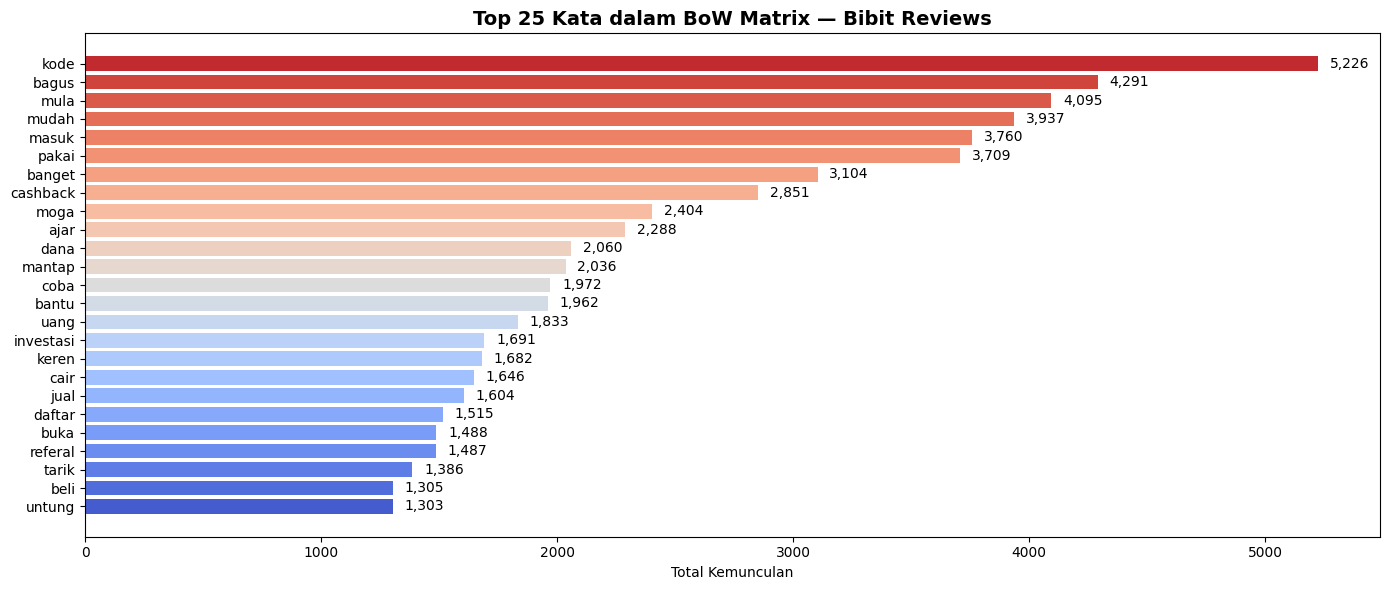

In [ ]:
# Hitung total frekuensi setiap kata dalam BoW matrix
bow_word_freq = pd.Series(
    bow_array.sum(axis=0),
    index=feature_names
).sort_values(ascending=False)

# Bar chart Top 25 kata dalam BoW
top_25 = bow_word_freq.head(25)

plt.figure(figsize=(14, 6))
palette = sns.color_palette("coolwarm", len(top_25))
bars = plt.barh(top_25.index[::-1], top_25.values[::-1], color=palette)
plt.title('Top 25 Kata dalam BoW Matrix — Bibit Reviews', fontsize=14, fontweight='bold')
plt.xlabel('Total Kemunculan')
for bar, val in zip(bars, top_25.values[::-1]):
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'{int(val):,}', va='center')
plt.tight_layout()
plt.show()

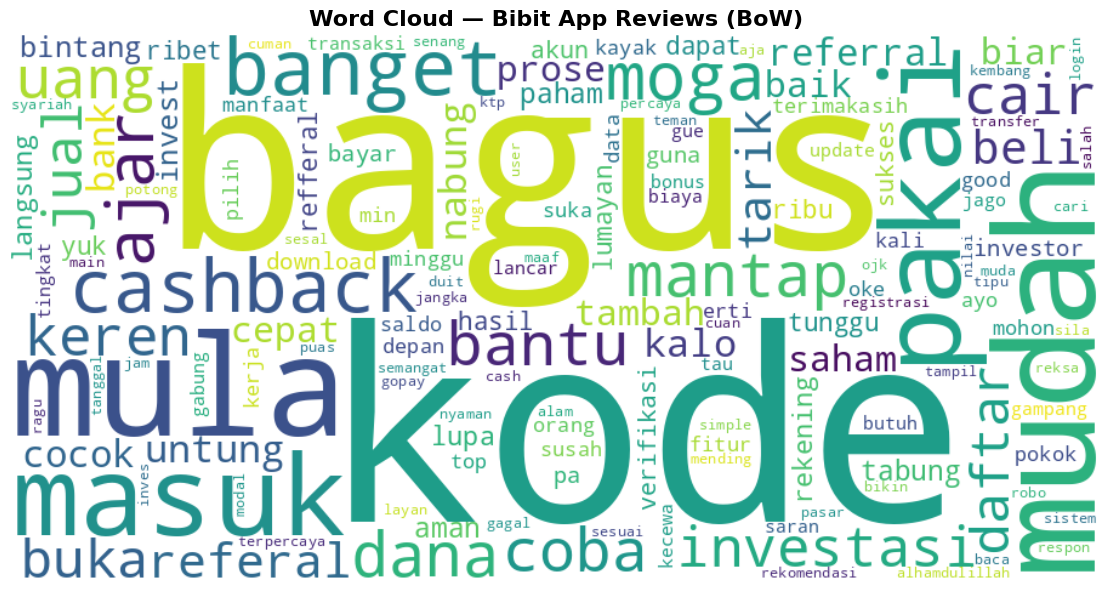

In [ ]:
# Word Cloud dari BoW
word_freq_dict = bow_word_freq.to_dict()

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color='white',
    colormap='viridis',
    max_words=150,
    prefer_horizontal=0.85
).generate_from_frequencies(word_freq_dict)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud — Bibit App Reviews (BoW)', fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 7. BoW per Kelas Sentimen

Kita analisis kata-kata dominan untuk masing-masing kelas sentimen: **positive**, **negative**, dan **neutral**.

In [ ]:
# Pisahkan corpus per sentimen
sentiments = ['positive', 'negative', 'neutral']
colors_map = {'positive': '#4CAF50', 'negative': '#F44336', 'neutral': '#2196F3'}

sentiment_corpora = {}
for sent in sentiments:
    mask = corpus_df['sentiment'] == sent
    sentiment_corpora[sent] = corpus_df[mask]['processed_text'].tolist()
    print(f"{sent:>10}: {len(sentiment_corpora[sent]):,} dokumen")

  positive: 26,957 dokumen
  negative: 6,946 dokumen
   neutral: 2,193 dokumen


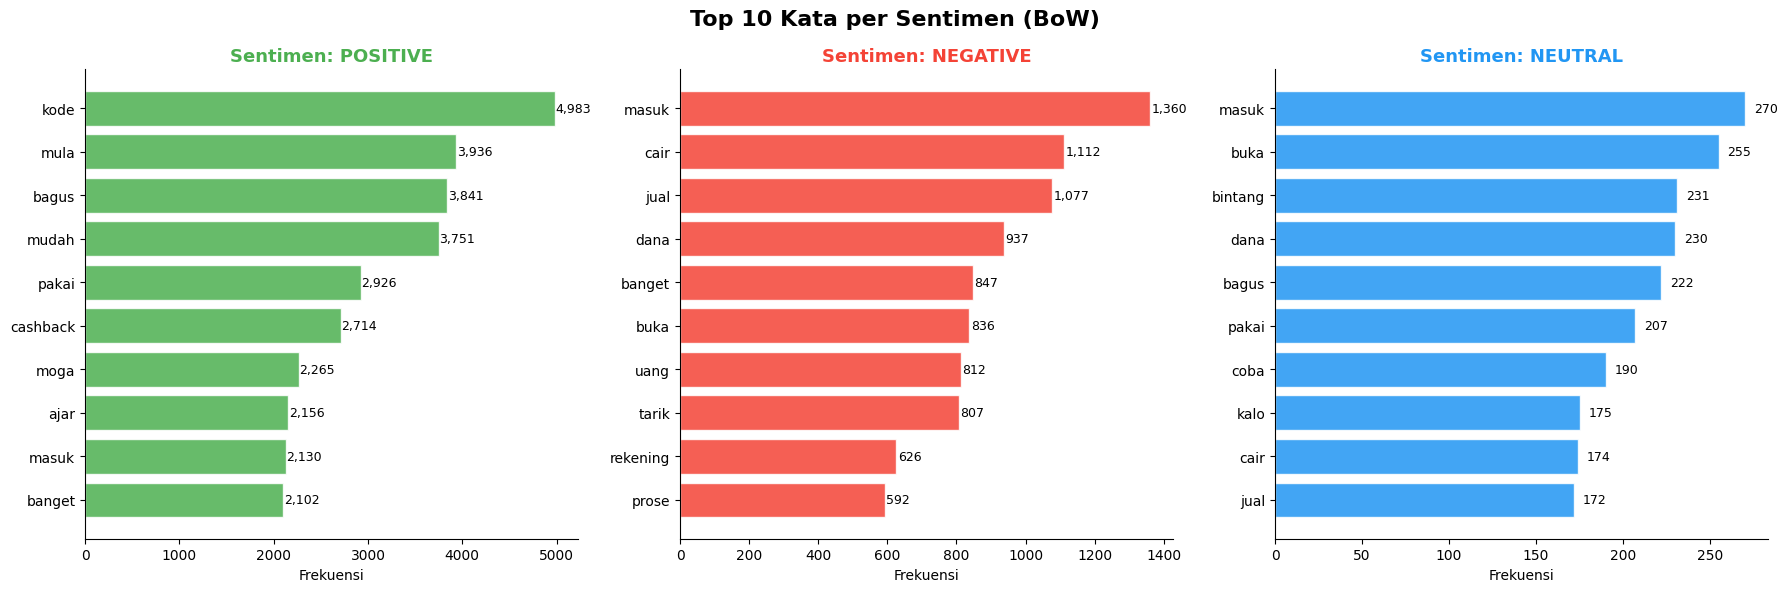

In [ ]:
# Buat BoW per sentimen & ambil top 10 kata
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Top 10 Kata per Sentimen (BoW)', fontsize=16, fontweight='bold')

for ax, sent in zip(axes, sentiments):
    # CountVectorizer per sentimen
    cv_sent = CountVectorizer(max_features=500, min_df=2)
    matrix_sent = cv_sent.fit_transform(sentiment_corpora[sent])

    # Hitung frekuensi
    freq_sent = pd.Series(
        matrix_sent.toarray().sum(axis=0),
        index=cv_sent.get_feature_names_out()
    ).sort_values(ascending=False).head(10)

    # Plot
    bars = ax.barh(freq_sent.index[::-1], freq_sent.values[::-1],
                   color=colors_map[sent], edgecolor='white', alpha=0.85)
    ax.set_title(f'Sentimen: {sent.upper()}', fontweight='bold',
                 color=colors_map[sent], fontsize=13)
    ax.set_xlabel('Frekuensi')
    for bar, val in zip(bars, freq_sent.values[::-1]):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f'{int(val):,}', va='center', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

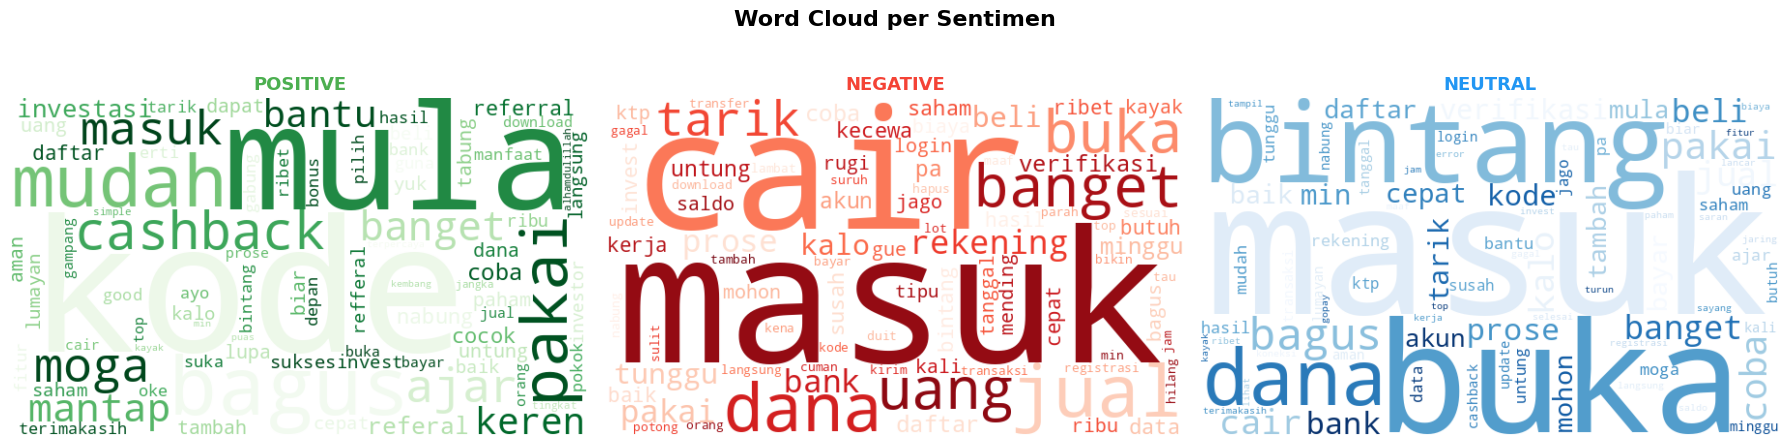

In [ ]:
# Word Cloud per sentimen
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Word Cloud per Sentimen', fontsize=16, fontweight='bold')

cmaps = {'positive': 'Greens', 'negative': 'Reds', 'neutral': 'Blues'}

for ax, sent in zip(axes, sentiments):
    cv_wc = CountVectorizer(max_features=300, min_df=2)
    matrix_wc = cv_wc.fit_transform(sentiment_corpora[sent])
    freq_wc = dict(zip(
        cv_wc.get_feature_names_out(),
        matrix_wc.toarray().sum(axis=0)
    ))

    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=cmaps[sent],
        max_words=80
    ).generate_from_frequencies(freq_wc)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(sent.upper(), fontweight='bold',
                 color=colors_map[sent], fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Ringkasan

| Langkah | Deskripsi | Hasil |
|---------|-----------|-------|
| **1. Dataset** | Load `bibit_reviews_cleaned.csv` | 36,237 ulasan (pos/neg/neutral) |
| **2. Preprocessing** | Tokenisasi, stopword removal, lemmatisasi | Corpus siap |
| **3. Unique Words** | Hitung frekuensi seluruh kata | Ribuan kata unik |
| **4. Mapping** | Word → Nomor (urut frekuensi) | Vocabulary terstruktur |
| **5. BoW Matrix** | `CountVectorizer` (max_features=1000) | Matrix dokumen × kata |
| **6. Visualisasi** | Bar chart, Word Cloud | Kata dominan terlihat jelas |
| **7. Per Sentimen** | BoW untuk setiap kelas | Kata khas pos/neg/neutral |

### Kata-kata Khas per Sentimen
- **Positive:** bagus, mudah, mantap, aman, investasi, nabung, reksa, dana
- **Negative:** lama, tarik, masuk, minus, buka, error, suspend, kuota
- **Neutral:** proses, verifikasi, cair, dana, langsung, registrasi